## baseline 逐维扫描，每次确定一个最优参数

In [1]:
import time
import numpy as np
import os
import sys

# 将目录添加到 Python 路径
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO')
sys.path.append('/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO/tutorials/scao_system/myAoSystem')
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.ShackHartmann import ShackHartmann
from tutorials.scao_system.myAoSystem.Imager_new import Imager_new  # 导入新的科学相机模块
from tutorials.scao_system.myAoSystem.Imager import Imager # 导入之前的的科学相机模块
import matplotlib.pyplot as plt
import OOPAO.tools.displayTools as tools
import importlib
from OOPAO.calibration.ao_calibration import ao_calibration
def load_parameter_file(file_name):
    """动态加载指定参数文件"""
    try:
        module = importlib.import_module(f'envs.paramsettings.{file_name}')
        return module.initializeParameterFile()
    except ImportError:
        raise ValueError(f"参数文件 {file_name} 不存在")



     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2


In [2]:
import csv
import os
from datetime import datetime

log_file = ''
def log_result(stage, gain, samplingRate, clockRate, exposureTime, SR_mean, SR_std, WFE, Return):

    os.makedirs(os.path.dirname(log_file), exist_ok=True)

    file_exists = os.path.isfile(log_file)

    with open(log_file, 'a', newline='') as f:
        writer = csv.writer(f)

        if not file_exists:
            writer.writerow([
                "timestamp",
                "stage",
                "gain",
                "samplingRate",
                "clockRate",
                "exposureTime",
                "SR_mean",
                "SR_std",
                "WFE",
                "Return"
            ])

        writer.writerow([
            datetime.now().isoformat(),
            stage,
            gain,
            samplingRate,
            clockRate,
            exposureTime,
            SR_mean,
            SR_std,
            WFE,
            Return
        ])

In [3]:
def calculate_reward(action, sr, index, residual):
    w = {
        "base_reward_scale": 1.0,       # 基础奖励放大倍数
        "turb_penalty_scale": 0.1,       # 湍流惩罚系数
        "gain_penalty_scale": 0.1,       # 增益约束惩罚系数
        "freq_gain_penalty_scale": 0.1,  # 采样频率与增益约束惩罚系数
        "freq_expo_penalty_scale": 0.2,  # 曝光时间与采样频率乘积约束惩罚系数
        "clock_penalty_scale": 0.1,      # 时钟频率与曝光时间约束惩罚系数
        "volt_penalty_scale": 0.1        # 电压波动惩罚系数
    }
    """优化奖励函数（新增湍流惩罚）"""
    # 基础奖励（保持原有计算方式）
    # 解包动作参数
    gain, sample_freq, exposure, clock_freq = action

    # 计算奖励
    # """将WFE压缩到[0,1]范围，100nm为0.5，两端渐进饱和"""
    # normalized_wfe = 0.5 * (np.tanh((self.residual[self.current_step] - 100) / 300) + 1)  # 300控制斜率
    # if self.residual[self.current_step] < 100:     # 波前误差<100:超高性能奖励
    #     reward = self.actual_SR[self.current_step] * w["base_reward_scale"] + (1 - normalized_wfe)
    # else:
    #     reward = self.actual_SR[self.current_step] * w["base_reward_scale"] - 0.3 * normalized_wfe

    # === 主奖励：SR ===
    reward = sr * w["base_reward_scale"]

    # === WFE shaping reward（仅稳态后） ===
    if index > 10:   # 10步后变化
        delta_wfe = residual[index - 1] - residual[index]
        reward += 0.01 * delta_wfe


    # 约束1: 曝光时间↑ → 增益↓ (反向关系约束)
    # 理想比例：曝光时间占最大值时，增益应接近最小值
    gain_penalty = np.abs(gain - (1.0 - 0.9 * (exposure - 0.1) / 0.9))  # 线性惩罚项
    reward -= w["gain_penalty_scale"] * gain_penalty

    # 约束2: 采样频率↑ → 增益↑ (正向关系约束)
    # 理想比例：采样频率2000Hz时增益应接近1.0，100Hz时接近0.1
    desired_gain = 0.1 + 0.9 * (sample_freq - 100) / 1900
    freq_gain_penalty = np.abs(gain - desired_gain)
    reward -= w["freq_gain_penalty_scale"] * freq_gain_penalty

    # 约束3: 曝光时间↑ → 采样频率↓ (反向关系约束)
    # 限制曝光时间×采样频率的乘积不超过阈值（如500）
    freq_exposure_penalty = max(0, (exposure * sample_freq - 500) / 500)
    reward -= w["freq_expo_penalty_scale"] * freq_exposure_penalty  # 强惩罚越界行为

    # 约束4: 时钟频率↑ → 曝光时间↓ (反向关系约束)
    # 理想关系：曝光时间 ∝ 1/clock_freq
    desired_exposure = 1.0 / (clock_freq / 500)  # 基准值500Hz时曝光1.0
    clock_penalty = np.abs(exposure - desired_exposure)
    reward -= w["clock_penalty_scale"] * clock_penalty        
    
    # # 新增时序同步惩罚（保持原有逻辑）
    # tel_freq, cam_freq = action[1], action[3]
    # if abs(tel_freq - cam_freq) > 100:
    #     reward -= 1

        
    return reward

In [4]:
def run_baseline(paramFile='',frames=500):
    param = load_parameter_file(paramFile)
    param['samplingRate'] = 1000
    param['exposureTime'] = 1
    param['clockRate'] = 1000
    tel = Telescope(resolution         =   param['resolution'], 
                        diameter           =   param['diameter'], 
                        samplingTime       =   1/param['samplingRate'], 
                        centralObstruction =   param['centralObstruction'])

    ngs = Source(magnitude             =   param['magnitude'],
                        optBand               =   param['opticalBand'])
    ngs * tel
    atm = Atmosphere(telescope         =   tel, 
                            r0                =   param['r0'], 
                            L0                =   param['L0'], 
                            windSpeed         =   param['windSpeed'],
                            fractionalR0      =   param['fractionnalR0'], 
                            windDirection     =   param['windDirection'],
                            altitude          =   param['altitude'])

    dm = DeformableMirror(telescope    =   tel, 
                                nSubap       =   param['nSubap'], 
                                mechCoupling =   param['mechCoupling'])

    wfs = ShackHartmann(nSubap         =   param['nSubap'], 
                                telescope      =   tel, 
                                lightRatio     =   param['lightRatio'], 
                                is_geometric   =   param['is_geometric'], 
                                threshold_cog  =   param['threshold_cog'])


    camH = Imager(exposure_time=param['exposureTime'], 
                        clock_rate=param['clockRate'],
                        nyquist_sampling=param['nyquist_sampling'],
                        field_stop_size=param['field_stop_size'])
    
    ao_calib = ao_calibration(param=param, \
                                ngs=ngs, \
                                tel=tel, \
                                atm=atm, \
                                dm=dm, \
                                wfs=wfs, \
                                nameFolderIntMat=None, \
                                nameIntMat=None, \
                                nameFolderBasis=None, \
                                nameBasis=None, \
                                nMeasurements=100)
    calib_CL = ao_calib.calib  # 交互矩阵
    M2C_CL = ao_calib.M2C
    wfs.cam.photonNoise                =   param['photonNoise']
    wfs.cam.readoutNoise               =   param['readoutNoise']
    wfs.cam.darkCurrent                =   param['darkCurrent']

    # ---------- 单次仿真 ----------
    def run(gainCL=0.1):
        atm.initializeAtmosphere(telescope=tel)
        dm.coefs = 0
        tel-atm
        ngs * tel * dm * wfs
        camH.relay(tel.src)
        camH.reference_frame = camH.frame
        
        actual_SR  = np.zeros(frames)
        SR_old = np.zeros(frames)
        residual = np.zeros(frames)
        dm.coefs = 0
        wfsSignal = np.zeros(wfs.nSignal)
        Return = 0
        for current_step in range(frames):
            # 更新大气湍流相位屏
            atm.update()
            tel-atm
            camH.relay(tel.src)
            camH.reference_frame = camH.frame
            tel+atm

            # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 波前传感器
            ngs * tel * dm * wfs

            
            # # 存入队列
            # wfs_buffer.append(wfsSignal)

            # # 取出延迟后的信号
            # delayed_signal = wfs_buffer[0]
            # # 更新变形镜控制信号
            # dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ delayed_signal
            dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ wfsSignal
            wfsSignal = wfs.signal.copy()


            camH.relay(tel.src)
            SR_old[current_step]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))
            # 计算斯特列尔比（基于科学相机的PSF）
            actual_SR[current_step] = camH.strehl
            residual[current_step]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
            Return += calculate_reward([gainCL, 1/tel.samplingTime, camH.exposure_time, camH.clock_rate], camH.strehl, current_step, residual)

        SR_mean = np.mean(actual_SR)
        SR_std  = np.std(actual_SR[10:])
        WFE = np.mean(residual)
        print(wfs.cam.photonNoise)
        return SR_mean, SR_std, WFE, Return, np.mean(SR_old)


    # ==========================================================
    # === 1️⃣ 扫描 gain
    # ==========================================================

    gains = np.arange(0.1,1.1,0.1)

    best_gain = None
    best_SR_mean = -1
    best_SR_std = 0
    best_WFE = 0
    best_Return = 0

    print("\nScanning Gain")

    for g in gains:

        SR_mean, SR_std, WFE, Return, SR_old_mean = run(g)

        print(f"gain={g:.2f} SR={SR_mean:.4f} Return={Return:.4f} SR_old_mean={SR_old_mean:.4f}")

        log_result(
            stage="gain_scan",
            gain=g,
            samplingRate=param['samplingRate'],
            clockRate=param['clockRate'],
            exposureTime=param['exposureTime'],
            SR_mean=SR_mean,
            SR_std=SR_std,
            WFE=WFE,
            Return=Return
        )

        if Return > best_Return:
            best_SR_mean = SR_mean
            best_SR_std = SR_std
            best_WFE = WFE
            best_gain = g

            best_Return = Return
    print("Best Gain:",best_gain)


    # ==========================================================
    # === 2️⃣ 扫描 samplingRate
    # ==========================================================

    sampling_rates = np.arange(200,2200,200)

    best_rate = None
    best_SR_mean = -1
    best_SR_std = 0
    best_WFE = 0
    best_Return = 0

    print("\nScanning samplingRate")

    for r in sampling_rates:

        tel.samplingTime = 1/r

        SR_mean, SR_std, WFE, Return, SR_old_mean = run(best_gain)

        log_result(
            stage="samplingRate_scan",
            gain=best_gain,
            samplingRate=r,
            clockRate=param['clockRate'],
            exposureTime=param['exposureTime'],
            SR_mean=SR_mean,
            SR_std=SR_std,
            WFE=WFE,
            Return=Return
        )

        print(f"rate={r} SR={SR_mean:.4f} Return={Return:.4f} SR_old_mean={SR_old_mean:.4f}")

        if Return > best_Return:
            best_SR_mean = SR_mean
            best_SR_std = SR_std
            best_WFE = WFE
            best_rate = r

            best_Return = Return

    param['samplingRate'] = best_rate
    tel.samplingTime = 1/best_rate

    print("Best samplingRate:",best_rate)


    # ==========================================================
    # === 3️⃣ 扫描 clockRate
    # ==========================================================

    clock_rates = np.arange(200,2200,200)

    best_clock = None
    best_SR_mean = -1
    best_SR_std = 0
    best_WFE = 0
    best_Return = 0


    print("\nScanning clockRate")

    for c in clock_rates:

        camH.clock_rate = c

        SR_mean, SR_std, WFE,Return, SR_old_mean = run(best_gain)

        log_result(
            stage="clockRate_scan",
            gain=best_gain,
            samplingRate=param['samplingRate'],
            clockRate=c,
            exposureTime=param['exposureTime'],
            SR_mean=SR_mean,
            SR_std=SR_std,
            WFE=WFE,
            Return=Return
        )

        print(f"clock={c} SR={SR_mean:.4f} Return={Return:.4f} SR_old_mean={SR_old_mean:.4f}")

        if Return > best_Return:
            best_SR_mean = SR_mean
            best_SR_std = SR_std
            best_WFE = WFE
            best_clock = c

            best_Return = Return

    param['clockRate'] = best_clock
    camH.clock_rate = best_clock

    print("Best clockRate:",best_clock)


    # ==========================================================
    # === 4️⃣ 扫描 exposureTime
    # ==========================================================

    exposure_times = np.arange(0.1,1.1,0.1)

    best_exp = None
    best_SR_mean = -1
    best_SR_std = 0
    best_WFE = 0
    best_Return = 0

    print("\nScanning exposureTime")

    for e in exposure_times:

        camH.exposure_time = e

        SR_mean, SR_std, WFE,Return, SR_old_mean = run(best_gain)

        log_result(
            stage="exposureTime_scan",
            gain=best_gain,
            samplingRate=param['samplingRate'],
            clockRate=param['clockRate'],
            exposureTime=e,
            SR_mean=SR_mean,
            SR_std=SR_std,
            WFE=WFE,
            Return=Return
        )

        print(f"exp={e} SR={SR_mean:.4f} Return={Return:.4f} SR_old_mean={SR_old_mean:.4f}")

        if Return > best_Return:
            best_SR_mean = SR_mean
            best_SR_std = SR_std
            best_WFE = WFE
            best_exp = e

            best_Return = Return

    param['exposureTime'] = best_exp
    camH.exposure_time = best_exp

    print("Best exposureTime:",best_exp)


    # ==========================================================
    # 最终结果
    # ==========================================================

    print("\nFinal optimized parameters")

    print("Gain:",best_gain)
    print("SamplingRate:",best_rate)
    print("ClockRate:",best_clock)
    print("ExposureTime:",best_exp)
    log_result(
        stage="baseline",
        gain=best_gain,
        samplingRate=param['samplingRate'],
        clockRate=param['clockRate'],
        exposureTime=param['exposureTime'],
        SR_mean=best_SR_mean,
        SR_std=best_SR_std,
        WFE=best_WFE,
        Return=best_Return
    )



In [10]:
log_file = "baseline_scan_log/1-1.csv"
run_baseline(paramFile='1-1',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [01:06<08:52, 66.55s/it]

100/856
Time elapsed: 66.54822087287903 s


 22%|██▏       | 2/9 [01:43<05:44, 49.16s/it]

200/856
Time elapsed: 36.92428922653198 s


...

 89%|████████▉ | 8/9 [11:28<01:43, 103.86s/it]

800/856
Time elapsed: 123.532381772995 s


100%|██████████| 9/9 [12:24<00:00, 82.76s/it] 

900/856
Time elapsed: 56.46459150314331 s


No Modal Gains found. All gains set to 1

Scanning Gain
-> Computing the initial phase screen...
initial phase screen : 0.029791831970214844 s
ZZt.. : 39.11279845237732 s
ZXt.. : 0.5875918865203857 s
XXt.. : 0.29286694526672363 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.02780604362487793 s
ZZt.. : 7.152557373046875e-07 s
ZXt.. : 4.458427429199219e-05 s
XXt.. : 1.0728836059570312e-05 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.03911542892456055 s
ZZt.. : 2.6226043701171875e-06 s
ZXt.. : 3.647804260253906e-05 s
XXt.. : 7.867813110351562e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
gain=0.10 SR=0.1759 Return=-58.7345 SR_old_mean=0.1154
True
gain=0.20 SR=0.3863 Return=46.5046 SR_old_mean=0.3441
True
gain=0.30 SR=0.5116 Return=109.2130 SR_old_mean=0.4790
True
gain=0.40 SR=0.5800 Return=143.4209 SR_old_mean=0.5479
True
gain=0.5

In [5]:
log_file = "baseline_scan_log/1-2.csv"
run_baseline(paramFile='1-2',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:08<01:06,  8.34s/it]

100/856
Time elapsed: 8.342815637588501 s


 22%|██▏       | 2/9 [00:16<00:57,  8.22s/it]

200/856
Time elapsed: 8.130797863006592 s


...

 89%|████████▉ | 8/9 [01:03<00:07,  7.79s/it]

800/856
Time elapsed: 7.653431415557861 s


100%|██████████| 9/9 [01:07<00:00,  7.50s/it]

900/856
Time elapsed: 4.193956136703491 s


No Modal Gains found. All gains set to 1

Scanning Gain
-> Computing the initial phase screen...
initial phase screen : 0.019568204879760742 s
ZZt.. : 11.113376140594482 s
ZXt.. : 0.5585589408874512 s
XXt.. : 0.2842588424682617 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.022052526473999023 s
ZZt.. : 1.6689300537109375e-06 s
ZXt.. : 3.814697265625e-05 s
XXt.. : 6.67572021484375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.022072792053222656 s
ZZt.. : 2.86102294921875e-06 s
ZXt.. : 3.24249267578125e-05 s
XXt.. : 6.4373016357421875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
gain=0.10 SR=0.2098 Return=-41.8861 SR_old_mean=0.1672
True
gain=0.20 SR=0.4320 Return=69.2955 SR_old_mean=0.3867
True
gain=0.30 SR=0.5584 Return=132.5631 SR_old_mean=0.5087
True
gain=0.40 SR=0.6225 Return=164.6267 SR_old_mean=0.5699
True
gain=0.50 SR

In [6]:
log_file = "baseline_scan_log/1-3.csv"
run_baseline(paramFile='1-3',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:08<01:08,  8.55s/it]

100/856
Time elapsed: 8.55388617515564 s


 22%|██▏       | 2/9 [00:16<00:58,  8.31s/it]

200/856
Time elapsed: 8.140806436538696 s


...

 89%|████████▉ | 8/9 [01:05<00:08,  8.22s/it]

800/856
Time elapsed: 8.28840684890747 s


100%|██████████| 9/9 [01:10<00:00,  7.82s/it]

900/856
Time elapsed: 4.66951060295105 s


No Modal Gains found. All gains set to 1

Scanning Gain
-> Computing the initial phase screen...
initial phase screen : 0.023628950119018555 s
ZZt.. : 11.518229007720947 s
ZXt.. : 0.5688796043395996 s
XXt.. : 0.28110647201538086 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.021184921264648438 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 3.218650817871094e-05 s
XXt.. : 6.67572021484375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.021480798721313477 s
ZZt.. : 7.152557373046875e-07 s
ZXt.. : 4.076957702636719e-05 s
XXt.. : 6.67572021484375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
gain=0.10 SR=0.1765 Return=-58.3848 SR_old_mean=0.1026
True
gain=0.20 SR=0.3825 Return=44.6522 SR_old_mean=0.3187
True
gain=0.30 SR=0.5157 Return=111.3468 SR_old_mean=0.4619
True
gain=0.40 SR=0.5863 Return=146.6202 SR_old_mean=0.5382
True
gain=0.50 

In [5]:
log_file = "baseline_scan_log/2-1.csv"
run_baseline(paramFile='2-1',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:11<01:29, 11.18s/it]

100/856
Time elapsed: 11.184091091156006 s


 22%|██▏       | 2/9 [00:19<01:04,  9.21s/it]

200/856
Time elapsed: 7.829022169113159 s


...

 89%|████████▉ | 8/9 [01:04<00:07,  7.73s/it]

800/856
Time elapsed: 7.603236198425293 s


100%|██████████| 9/9 [01:09<00:00,  7.67s/it]

900/856
Time elapsed: 4.1381754875183105 s


No Modal Gains found. All gains set to 1

Scanning Gain
-> Computing the initial phase screen...
initial phase screen : 0.019945144653320312 s
ZZt.. : 10.955764293670654 s
ZXt.. : 0.5548629760742188 s
XXt.. : 0.2762000560760498 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.022335052490234375 s
ZZt.. : 1.9073486328125e-06 s
ZXt.. : 3.647804260253906e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.021245479583740234 s
ZZt.. : 3.5762786865234375e-06 s
ZXt.. : 3.337860107421875e-05 s
XXt.. : 7.3909759521484375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
gain=0.10 SR=0.2466 Return=-23.0688 SR_old_mean=0.1921
True
gain=0.20 SR=0.4787 Return=92.8682 SR_old_mean=0.4510
True
gain=0.30 SR=0.5909 Return=148.9969 SR_old_mean=0.5704
True
gain=0.40 SR=0.6467 Return=176.9435 SR_old_mean=0.6242
True
gain=0.5

In [ ]:
log_file = "baseline_scan_log/2-2.csv"
run_baseline(paramFile='2-2',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [01:50<14:42, 110.26s/it]

100/856
Time elapsed: 110.25888657569885 s


 22%|██▏       | 2/9 [05:24<19:59, 171.39s/it]

200/856
Time elapsed: 214.14184665679932 s


...

 89%|████████▉ | 8/9 [28:45<04:13, 253.23s/it]

800/856
Time elapsed: 304.8977928161621 s


100%|██████████| 9/9 [30:13<00:00, 201.52s/it]

900/856
Time elapsed: 88.13531804084778 s


No Modal Gains found. All gains set to 1

Scanning Gain
-> Computing the initial phase screen...
initial phase screen : 0.029998302459716797 s
ZZt.. : 21.317237377166748 s
ZXt.. : 0.6121363639831543 s
XXt.. : 0.30158519744873047 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.01863837242126465 s
ZZt.. : 9.5367431640625e-07 s
ZXt.. : 2.8133392333984375e-05 s
XXt.. : 7.62939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.01845264434814453 s
ZZt.. : 7.152557373046875e-07 s
ZXt.. : 2.6464462280273438e-05 s
XXt.. : 6.9141387939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
gain=0.10 SR=0.2544 Return=-18.8490 SR_old_mean=0.2042
True
gain=0.20 SR=0.4938 Return=100.6646 SR_old_mean=0.4541
True
gain=0.30 SR=0.6077 Return=157.6301 SR_old_mean=0.5713
True
gain=0.40 SR=0.6615 Return=184.5705 SR_old_mean=0.6233


In [ ]:
run_baseline(paramFile='2-3',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:19<02:35, 19.40s/it]

100/856
Time elapsed: 19.396236896514893 s


 22%|██▏       | 2/9 [00:38<02:12, 18.95s/it]

200/856
Time elapsed: 18.627798557281494 s


...

700/856
Time elapsed: 17.517300605773926 s


 89%|████████▉ | 8/9 [02:15<00:17, 17.02s/it]

800/856
Time elapsed: 18.329675436019897 s


100%|██████████| 9/9 [02:22<00:00, 15.86s/it]

900/856
Time elapsed: 6.9374401569366455 s


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:35<04:41, 35.13s/it]

100/856
Time elapsed: 35.1281259059906 s


 22%|██▏       | 2/9 [01:11<04:09, 35.64s/it]

200/856
Time elapsed: 35.98840689659119 s


...

 89%|████████▉ | 8/9 [04:09<00:28, 28.03s/it]

800/856
Time elapsed: 22.10365891456604 s


100%|██████████| 9/9 [04:18<00:00, 28.70s/it]

900/856
Time elapsed: 9.074923753738403 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.02713942527770996 s
ZZt.. : 18.88726544380188 s
ZXt.. : 0.907219648361206 s
XXt.. : 0.42241930961608887 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.05364632606506348 s
ZZt.. : 1.6689300537109375e-06 s
ZXt.. : 9.059906005859375e-05 s
XXt.. : 1.33514404296875e-05 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.02381443977355957 s
ZZt.. : 3.0994415283203125e-06 s
ZXt.. : 3.814697265625e-05 s
XXt.. : 7.62939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.1388,SR_std = 0.0273,WFE = 198.59
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.3445,SR_std = 0.0535,WFE = 136.97
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.4859,SR_std = 0.0439,WFE = 110.97
Runn

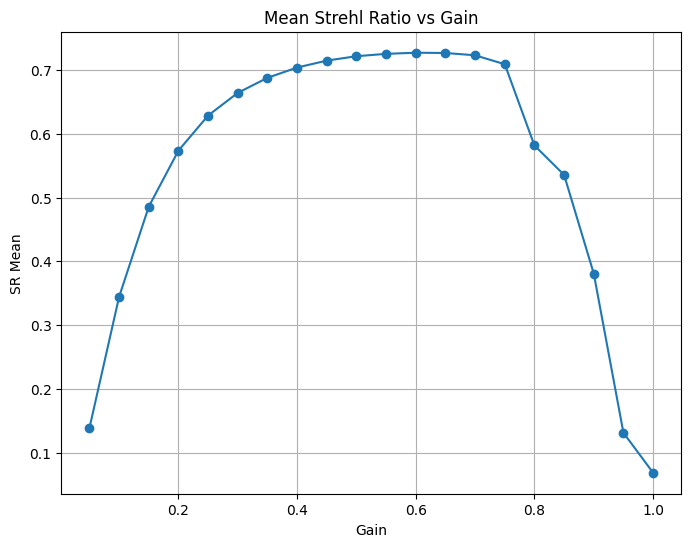

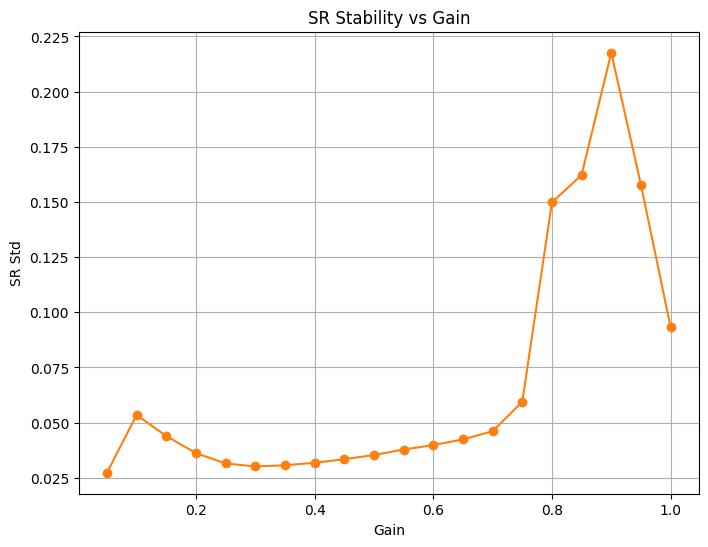

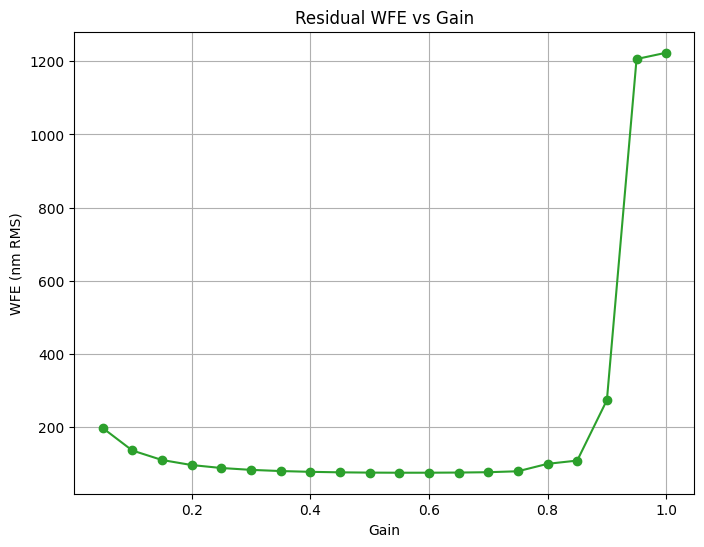

In [3]:
run_baseline(paramFile='3-1',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:32<04:21, 32.71s/it]

100/856
Time elapsed: 32.707823276519775 s


 22%|██▏       | 2/9 [00:57<03:18, 28.31s/it]

200/856
Time elapsed: 25.23125720024109 s


...

 89%|████████▉ | 8/9 [02:52<00:18, 18.87s/it]

800/856
Time elapsed: 16.63979721069336 s


100%|██████████| 9/9 [03:00<00:00, 20.03s/it]

900/856
Time elapsed: 7.450100898742676 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.04842352867126465 s
ZZt.. : 22.07497763633728 s
ZXt.. : 1.125565767288208 s
XXt.. : 0.5578186511993408 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.023073673248291016 s
ZZt.. : 7.152557373046875e-07 s
ZXt.. : 5.435943603515625e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.023955106735229492 s
ZZt.. : 9.5367431640625e-07 s
ZXt.. : 3.7670135498046875e-05 s
XXt.. : 8.344650268554688e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.1796,SR_std = 0.0623,WFE = 207.95
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.3660,SR_std = 0.0627,WFE = 143.89
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.5065,SR_std = 0.0523,WFE = 117.1

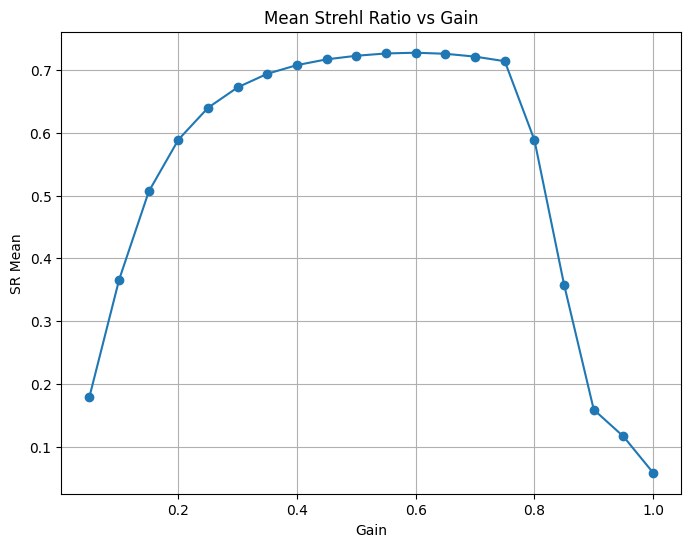

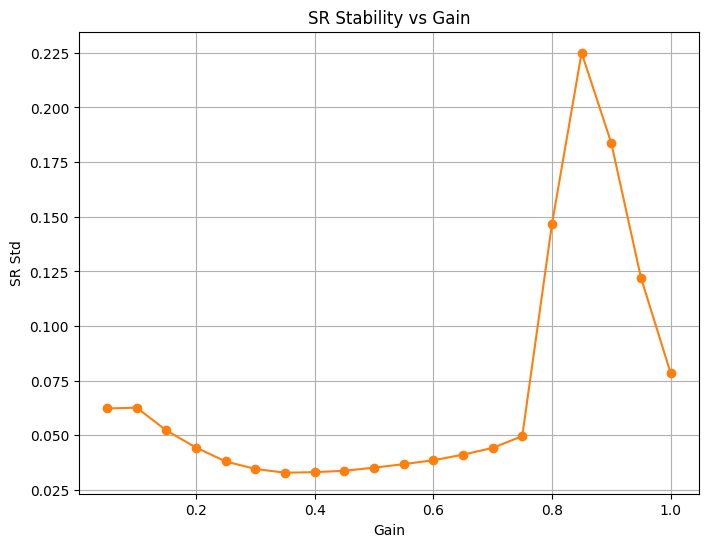

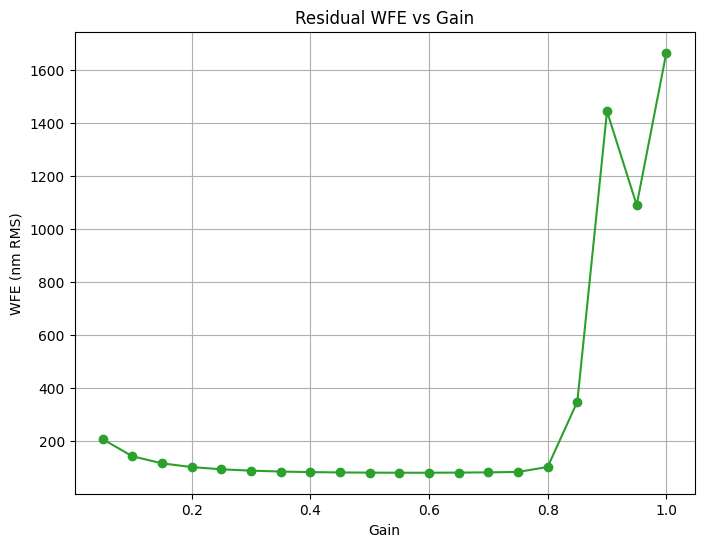

In [4]:
run_baseline(paramFile='3-2',frames=500)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           192             [pixels]     
    Pixel Size           0.02              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      27808            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       -0.0   7336956521.7
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates lo

 11%|█         | 1/9 [00:25<03:27, 25.89s/it]

100/856
Time elapsed: 25.88684105873108 s


 22%|██▏       | 2/9 [00:48<02:48, 24.12s/it]

200/856
Time elapsed: 22.886300802230835 s


...

 89%|████████▉ | 8/9 [02:33<00:17, 17.46s/it]

800/856
Time elapsed: 17.212839126586914 s


100%|██████████| 9/9 [02:40<00:00, 17.80s/it]

900/856
Time elapsed: 6.873744487762451 s


No Modal Gains found. All gains set to 1
Running gain = 0.05
-> Computing the initial phase screen...
initial phase screen : 0.05147290229797363 s
ZZt.. : 24.047648668289185 s
ZXt.. : 0.6248776912689209 s
XXt.. : 0.3176877498626709 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.025259017944335938 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 5.817413330078125e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.030828237533569336 s
ZZt.. : 1.6689300537109375e-06 s
ZXt.. : 5.269050598144531e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
True
Running gain = 0.05,SR_mean = 0.1496,SR_std = 0.0476,WFE = 218.52
Running gain = 0.10
True
Running gain = 0.10,SR_mean = 0.3576,SR_std = 0.0470,WFE = 145.58
Running gain = 0.15
True
Running gain = 0.15,SR_mean = 0.4990,SR_std = 0.0395,WFE = 11

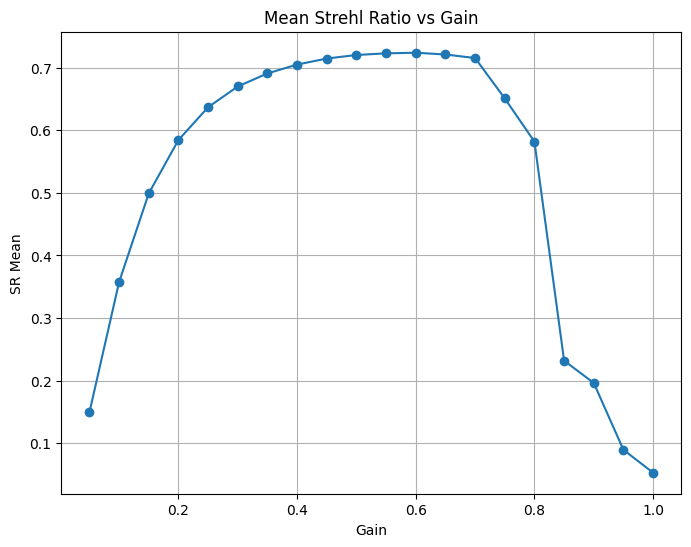

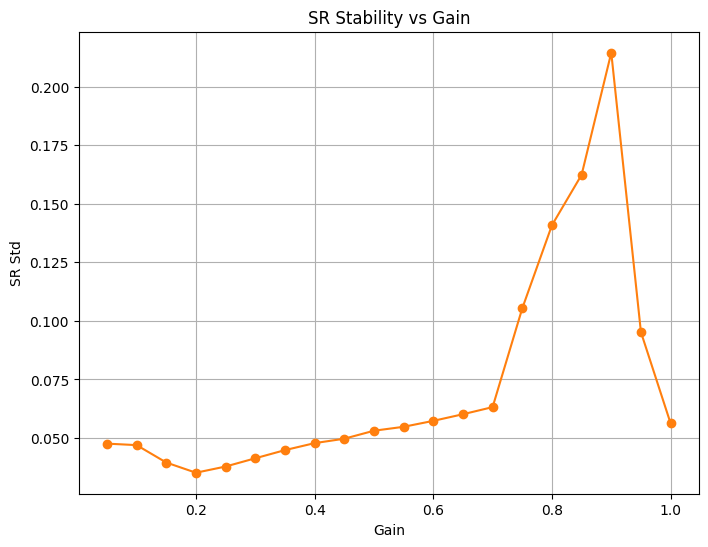

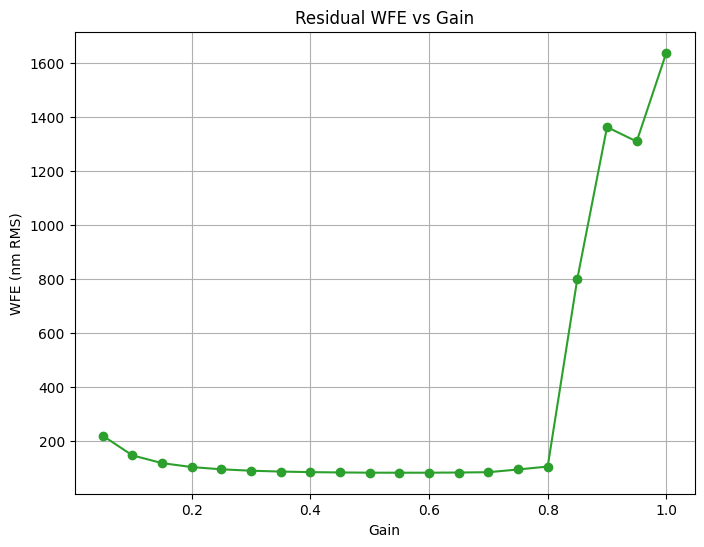

In [5]:
run_baseline(paramFile='3-3',frames=500)

In [2]:
param = load_parameter_file('paramFile3')
param['samplingRate'] = 1000
param['exposureTime'] = 1
param['clockRate'] = 1000
tel = Telescope(resolution         =   param['resolution'], 
                    diameter           =   param['diameter'], 
                    samplingTime       =   1/param['samplingRate'], 
                    centralObstruction =   param['centralObstruction'])

ngs = Source(magnitude             =   param['magnitude'],
                    optBand               =   param['opticalBand'])
ngs * tel
atm = Atmosphere(telescope         =   tel, 
                        r0                =   param['r0'], 
                        L0                =   param['L0'], 
                        windSpeed         =   param['windSpeed'],
                        fractionalR0      =   param['fractionnalR0'], 
                        windDirection     =   param['windDirection'],
                        altitude          =   param['altitude'])

dm = DeformableMirror(telescope    =   tel, 
                            nSubap       =   param['nSubap'], 
                            mechCoupling =   param['mechCoupling'])

wfs = ShackHartmann(nSubap         =   param['nSubap'], 
                            telescope      =   tel, 
                            lightRatio     =   param['lightRatio'], 
                            is_geometric   =   param['is_geometric'], 
                            threshold_cog  =   param['threshold_cog'])


camH = Imager(exposure_time=param['exposureTime'], 
                    clock_rate=param['clockRate'],
                    nyquist_sampling=param['nyquist_sampling'],
                    field_stop_size=param['field_stop_size'])
wfs.cam.photonNoise                =   param['photonNoise']
wfs.cam.readoutNoise               =   param['readoutNoise']
wfs.cam.darkCurrent                =   param['darkCurrent']
ao_calib = ao_calibration(param=param, \
                            ngs=ngs, \
                            tel=tel, \
                            atm=atm, \
                            dm=dm, \
                            wfs=wfs, \
                            nameFolderIntMat=None, \
                            nameIntMat=None, \
                            nameFolderBasis=None, \
                            nameBasis=None, \
                            nMeasurements=100)
calib_CL = ao_calib.calib  # 交互矩阵
M2C_CL = ao_calib.M2C


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304.3
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates load

 25%|██▌       | 1/4 [00:03<00:09,  3.28s/it]

100/357
Time elapsed: 3.2758965492248535 s


 50%|█████     | 2/4 [00:06<00:05,  2.99s/it]

200/357
Time elapsed: 2.783261299133301 s


 75%|███████▌  | 3/4 [00:08<00:02,  2.90s/it]

300/357
Time elapsed: 2.7887678146362305 s


100%|██████████| 4/4 [00:10<00:00,  2.62s/it]

400/357
Time elapsed: 1.6178319454193115 s


No Modal Gains found. All gains set to 1


In [15]:
import random
def run(frames=10):
    atm.initializeAtmosphere(telescope=tel)
    dm.coefs = 0
    calib_CL    = ao_calib.calib # 交互矩阵
    M2C_CL      = ao_calib.M2C 

    tel+atm
    ngs*tel*dm*wfs
    gainCL=0.5
    actual_SR  = np.zeros(frames)
    SR_old = np.zeros(frames)
    residual = np.zeros(frames)
    dm.coefs = 0
    wfsSignal = np.zeros(wfs.nSignal)
    for current_step in range(frames):
        
        # gainCL = 0.6
        # 更新大气湍流相位屏
        atm.update()
        tel-atm
        camH.relay(tel.src)
        camH.reference_frame = camH.frame
        tel+atm

        # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 波前传感器
        tel * dm * wfs

        
        # # 存入队列
        # wfs_buffer.append(wfsSignal)

        # # 取出延迟后的信号
        # delayed_signal = wfs_buffer[0]
        # # 更新变形镜控制信号
        # dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ delayed_signal
        dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ wfsSignal
        wfsSignal = wfs.signal.copy()

        camH.relay(tel.src)
        SR_old[current_step]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))
        # 计算斯特列尔比（基于科学相机的PSF）
        actual_SR[current_step] = camH.strehl
        residual[current_step]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
        print("step:{} ---  SR:{:.4f} ----SR_old:{:.4f}----WFE:{:.1f}-----gain:{}".
              format(current_step,camH.strehl,SR_old[current_step],residual[current_step],gainCL))
    print("平均SR:{:.4f}".format(np.mean(actual_SR)))
    plt.title("avg_SR:{:.4f}--std:{:.4f}".format(np.mean(actual_SR),np.std(actual_SR[9:])))
    plt.plot(actual_SR,label='SR')
    plt.plot(SR_old,label='SR_old')

step:0 ---  SR:0.0624 ----SR_old:0.0002----WFE:772.9-----gain:0.5
step:1 ---  SR:0.0621 ----SR_old:0.0002----WFE:773.6-----gain:0.5
step:2 ---  SR:0.1748 ----SR_old:0.0541----WFE:449.6-----gain:0.5
step:3 ---  SR:0.7452 ----SR_old:0.6966----WFE:158.3-----gain:0.5
step:4 ---  SR:0.7400 ----SR_old:0.7374----WFE:145.3-----gain:0.5
step:5 ---  SR:0.7210 ----SR_old:0.7188----WFE:151.2-----gain:0.5
step:6 ---  SR:0.8079 ----SR_old:0.8032----WFE:123.2-----gain:0.5
step:7 ---  SR:0.7833 ----SR_old:0.7463----WFE:142.4-----gain:0.5
step:8 ---  SR:0.7233 ----SR_old:0.6672----WFE:167.4-----gain:0.5
step:9 ---  SR:0.7193 ----SR_old:0.6625----WFE:168.9-----gain:0.5
平均SR:0.5539


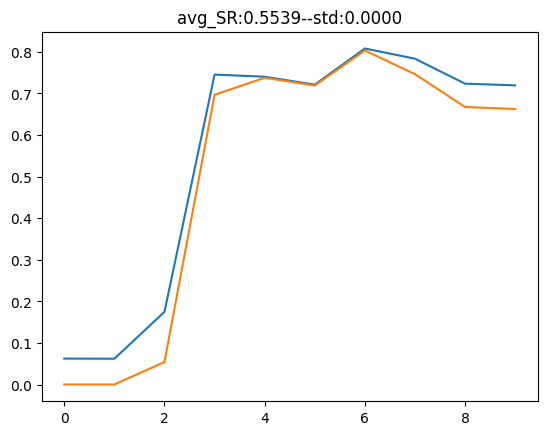

In [16]:
run(10)

In [6]:
atm.initializeAtmosphere(telescope=tel)

# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 10
# allocate memory to save data
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
SR_old                      = np.zeros(param['nLoop'])
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 1  # 传感增益

for i in range(param['nLoop']):
    a=time.time()

    atm.update()

    tel-atm
    camH.relay(tel.src)
    camH.reference_frame = camH.frame
    tel+atm
    # 记录总的波前误差
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    
    tel*dm*wfs

    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    
    wfsSignal=wfs.signal
    
    b= time.time()
    print('Elapsed time: ' + str(b-a) +' s')

    SR_old[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))  
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    camH.relay(tel.src)
    SR[i] = camH.strehl

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')

Elapsed time: 0.9795022010803223 s
Loop0/10 Turbulence: 772.8947459831028 -- Residual:772.8947459831028

Elapsed time: 0.9750392436981201 s
Loop1/10 Turbulence: 773.6216211083824 -- Residual:773.6216211083824

Elapsed time: 0.9901444911956787 s
Loop2/10 Turbulence: 774.3584543952883 -- Residual:158.9284186249703

Elapsed time: 0.9092702865600586 s
Loop3/10 Turbulence: 775.1150669351758 -- Residual:579.5527314186069

Elapsed time: 0.9048671722412109 s
Loop4/10 Turbulence: 775.9151956220711 -- Residual:600.5280016798051

Elapsed time: 0.9389975070953369 s
Loop5/10 Turbulence: 776.7150912551591 -- Residual:134.10249477357837

Elapsed time: 0.9153003692626953 s
Loop6/10 Turbulence: 777.4594580450279 -- Residual:680.8754996818848

Elapsed time: 0.9116940498352051 s
Loop7/10 Turbulence: 778.2202489369862 -- Residual:721.28127534991

Elapsed time: 0.9217889308929443 s
Loop8/10 Turbulence: 779.0131380137027 -- Residual:170.47171981285823

Elapsed time: 0.929955244064331 s
Loop9/10 Turbulence: 